### Problem Context
Traffic accidens are a major issue and has a major impact on economy and public safety

### Why this dataset
- Covers 49 US states
- 7.7M real world records
- Allows multidimensional analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("US_Accidents_March23.csv.zip")
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 46 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     object 
 1   Source                 object 
 2   Severity               int64  
 3   Start_Time             object 
 4   End_Time               object 
 5   Start_Lat              float64
 6   Start_Lng              float64
 7   End_Lat                float64
 8   End_Lng                float64
 9   Distance(mi)           float64
 10  Description            object 
 11  Street                 object 
 12  City                   object 
 13  County                 object 
 14  State                  object 
 15  Zipcode                object 
 16  Country                object 
 17  Timezone               object 
 18  Airport_Code           object 
 19  Weather_Timestamp      object 
 20  Temperature(F)         float64
 21  Wind_Chill(F)          float64
 22  Humidity(%)       

## *Memory Optimization*

The US Accidents dataset contains 7.7 million (77 lacs) records and 46 columns , when the dataset is initally loaded it sccupies approximately 9.5GB of RAM due to multiple default data types such as - object,int64 and float64

### Our purpose:
- To first optimize the memory so the data set can be loaded faster and funcitons can be   performed faster
- remove non-essential high memory columns
- convert timestamps into proper datetime format 

In [3]:
df.memory_usage(deep=True).sort_values(ascending=False).head(20)/(1024**3)

Description              0.848235
End_Time                 0.496190
Start_Time               0.496190
Weather_Timestamp        0.485408
Street                   0.432052
Timezone                 0.424866
ID                       0.416437
City                     0.415841
County                   0.410732
Weather_Condition        0.403925
Source                   0.403067
Zipcode                  0.399195
Airport_Code             0.381032
Sunrise_Sunset           0.378259
Civil_Twilight           0.377587
Nautical_Twilight        0.376878
Astronomical_Twilight    0.376317
Wind_Direction           0.369861
Country                  0.367079
State                    0.367079
dtype: float64

In [4]:
df.head(2)

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day


In [5]:
df.columns

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='object')

In [6]:
df['Turning_Loop'].value_counts()

Turning_Loop
False    7728394
Name: count, dtype: int64

In [7]:
df.drop(columns=['Description','Country','Airport_Code','Weather_Timestamp','Turning_Loop','Nautical_Twilight','Astronomical_Twilight','Civil_Twilight'],inplace=True)

In [8]:
df.columns

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Street', 'City',
       'County', 'State', 'Zipcode', 'Timezone', 'Temperature(F)',
       'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)',
       'Wind_Direction', 'Wind_Speed(mph)', 'Precipitation(in)',
       'Weather_Condition', 'Amenity', 'Bump', 'Crossing', 'Give_Way',
       'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop',
       'Traffic_Calming', 'Traffic_Signal', 'Sunrise_Sunset'],
      dtype='object')

In [9]:
datetime_cols=['Start_Time','End_Time']

for col in datetime_cols:
    df[col] = pd.to_datetime(df[col],format='mixed')

In [10]:
df['Sunrise_Sunset'].value_counts()

Sunrise_Sunset
Day      5334553
Night    2370595
Name: count, dtype: int64

In [11]:
category_cols = ['Source','City','County','State','Timezone','Wind_Direction','Weather_Condition','Sunrise_Sunset']

for col in category_cols:
    df[col] = df[col].astype('category')

In [12]:
int_cols = df.select_dtypes(include='float64').columns
for col in int_cols:
    df[col] = pd.to_numeric(df[col],downcast='integer')
float_cols = df.select_dtypes(include='float64').columns
for col in float_cols:
    df[col] = pd.to_numeric(df[col],downcast='float')
df.drop(columns='ID',inplace=True)

In [13]:
df['Zipcode']=df['Zipcode'].astype('category')
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 37 columns):
 #   Column             Dtype         
---  ------             -----         
 0   Source             category      
 1   Severity           int64         
 2   Start_Time         datetime64[ns]
 3   End_Time           datetime64[ns]
 4   Start_Lat          float32       
 5   Start_Lng          float32       
 6   End_Lat            float32       
 7   End_Lng            float32       
 8   Distance(mi)       float32       
 9   Street             object        
 10  City               category      
 11  County             category      
 12  State              category      
 13  Zipcode            category      
 14  Timezone           category      
 15  Temperature(F)     float32       
 16  Wind_Chill(F)      float32       
 17  Humidity(%)        float32       
 18  Pressure(in)       float32       
 19  Visibility(mi)     float32       
 20  Wind_Direction     categ

In [14]:
df.to_parquet("us_accidents_optimized.parquet",index=False)

## Memory Optimization Summary
Initial memory usage - 9.5GB
Final memory usage   - 758MB
Total reduced by     ~ 92

### Optimization methods used:
- Dropped non-useful text columns as description and street
- Downcasted numeric columns
- Parsed datetime columns
- Changed columns with repeated values to category dtype

### Why:
- reduced RAM usage
- improved speed
- prepared dataset for efficient EDA and future uses

## Future Analytical Focus

### We will aim to:
- Understand the distribution of accident severity
- Understand temporal patterns
- Weather imnpact on accidents
- Road infrastructure
- Other reasons accounting to accidents

## Key Questions
- Frequntly occuring accident patterns
- Accidents due to any environmental conditions
- What are the common occurences in high-severity incidents
- Predictive modeling modeling that can be build form this dataset

## Target Variable
The focus of this EDA would be the *Severity* Column , which tell sthe level of accidents on the scale of 1 to 4 
Comprehending this would give insights into patterns and support predictive modelling.

In [15]:
df['Severity'].value_counts().sort_index()

Severity
1      67366
2    6156981
3    1299337
4     204710
Name: count, dtype: int64

In [16]:
severity_count = df['Severity'].value_counts().sort_index()
severity_percentage = df['Severity'].value_counts(normalize=True).sort_index()*100
print(severity_count)
print(severity_percentage)

Severity
1      67366
2    6156981
3    1299337
4     204710
Name: count, dtype: int64
Severity
1     0.871669
2    79.667017
3    16.812510
4     2.648804
Name: proportion, dtype: float64


C:\Users\arthj\AppData\Local\Temp\ipykernel_29792\59457654.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x='Severity',palette="Reds")


Text(0.5, 1.0, 'Accident Severity Distribution')

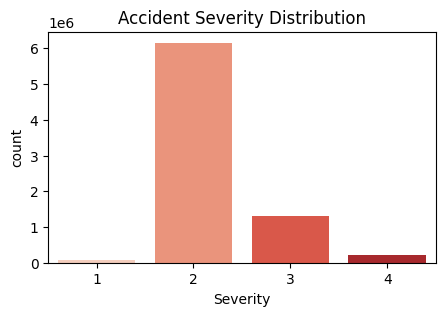

In [17]:
plt.figure(figsize=(5,3))
sns.countplot(data=df,x='Severity',palette="Reds")
plt.title("Accident Severity Distribution")

### *Observation*
Dataset is highly imbalanced , with severity comprising of almost 80% of the cases , whereas severe accidents represent only 2% of the cases
### *Interpretation*
This shows that moderate accidents are way more frequent than the severe ones which suggests that severe accidents may be rare events influenced by specific conditions.

In [18]:
df['Hour'] = df['Start_Time'].dt.hour
df['Year'] = df['Start_Time'].dt.year
df['Month'] = df['Start_Time'].dt.month
df['Day_of_week'] = df['Start_Time'].dt.day_name()

In [19]:
df.Hour.value_counts().sort_index()

Hour
0     112378
1      97071
2      93227
3      83863
4     159852
5     228182
6     405837
7     587472
8     577576
9     363034
10    342706
11    355040
12    355001
13    396445
14    448846
15    525855
16    581969
17    576015
18    432042
19    295121
20    225226
21    191452
22    167645
23    126539
Name: count, dtype: int64

<Axes: xlabel='Hour', ylabel='count'>

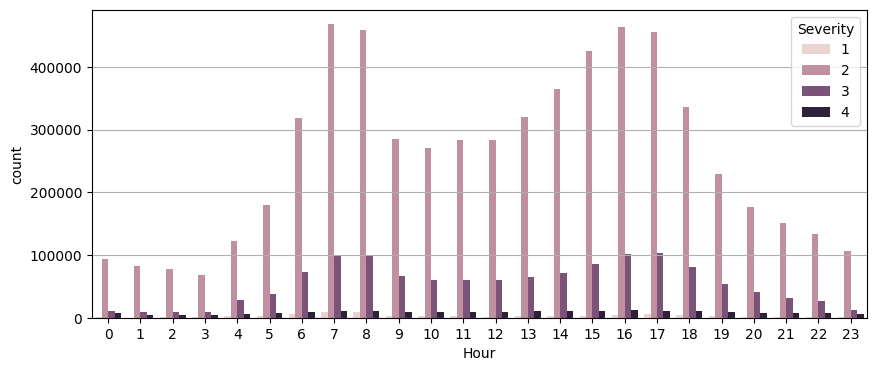

In [20]:
plt.figure(figsize=(10,4))
plt.grid(axis='y')
sns.countplot(data=df , x='Hour' , hue='Severity')

<Axes: xlabel='Day_of_week', ylabel='count'>

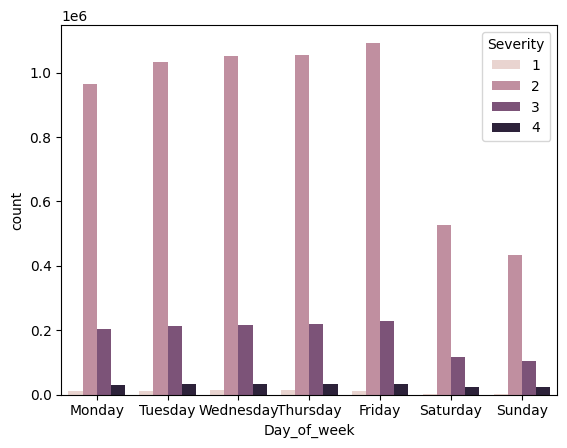

In [21]:
sns.countplot(data = df , x = 'Day_of_week' , hue='Severity')

In [22]:
pd.crosstab(df['Day_of_week'], df['Severity'], normalize='index') * 100

Severity,1,2,3,4
Day_of_week,,,,
Friday,0.883791,79.979056,16.719734,2.417419
Monday,0.953407,79.748225,16.731562,2.566807
Saturday,0.356522,78.651768,17.504408,3.487303
Sunday,0.392008,77.276346,18.421165,3.910481
Thursday,1.024974,80.003100,16.549552,2.422375
Tuesday,0.967830,80.017259,16.564583,2.450328
Wednesday,1.003437,80.127996,16.449086,2.419481


#### Observation:
- Accidents peak during rush hours ((7-9am) and (3-6pm)) , with common happenings of severity 2 incidents
- Severity 3 and 4 accidents are more seen during late night/morning hours(12am-4am)compared to daytime
- Saturday and sunday appear to have almost half of the accidents as compared to the rest of the week

#### Possible Explanation:
- During rush hours total accidents increase due to congestion on roads
- Late night severe accidents may be linked to rash driving , fatigue , poor visibility or poor driving
- Less people are driving a vehicle on the weekend due to it being a holiday for majority of the people

#### Implication
Better lightining and stricter monitoring at night could reduce severe road accidents.

<Axes: xlabel='Month', ylabel='count'>

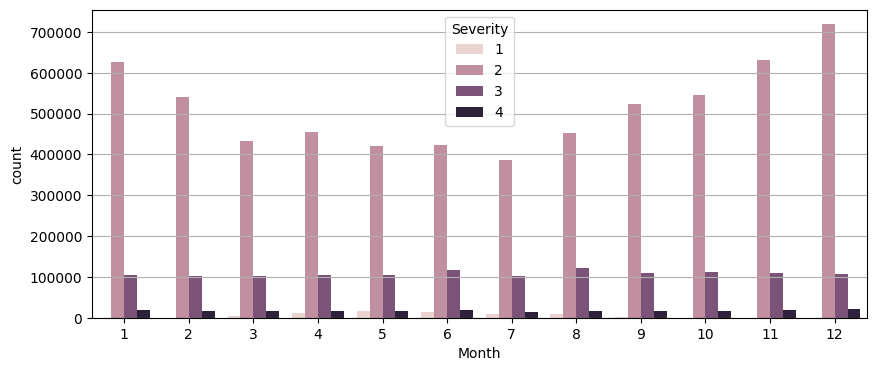

In [23]:
plt.figure(figsize=(10,4))
plt.grid(axis='y')
sns.countplot(data=df ,x='Month',hue='Severity')

<Axes: xlabel='Year', ylabel='count'>

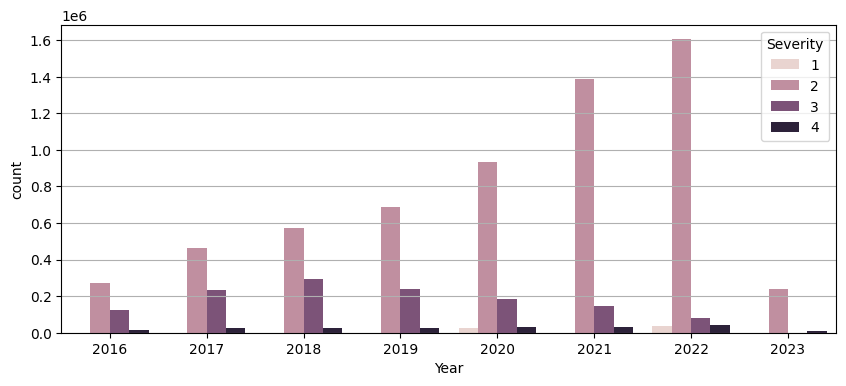

In [24]:
plt.figure(figsize=(10,4))
plt.grid(axis='y')
sns.countplot(data=df ,x='Year',hue='Severity')

#### Observation:
- Total reported accidents increase exponentially from 2016-2022 , majorly Severity 2
- Severity 3 and 4 incidents appear to be stable compared to total accidents
- Accidents are more prone to happen in the colder weather months wehreas they are less occuring in the clear weather months

#### Possible Explanation:
- Improvement in vehichle safety may be preventing chances of accidents to be turning severe
- Colder weather months provide with bad weather such as fog , mist , snow , rains,etc which may lead to accidents 

#### Implication
Accident trends overtime should take into account that the data reporting may also have improved over time so the model does not have misleading patterns

##### Note - 2023 appears to be lower as the dataset covers only a part of the year

In [25]:
df.Weather_Condition.nunique()

144

In [26]:
weather_value_head = df.Weather_Condition.value_counts().head(15)
weather_value_tail = df.Weather_Condition.value_counts().tail(10)
print(weather_value_head)

Weather_Condition
Fair                2560802
Mostly Cloudy       1016195
Cloudy               817082
Clear                808743
Partly Cloudy        698972
Overcast             382866
Light Rain           352957
Scattered Clouds     204829
Light Snow           128680
Fog                   99238
Rain                  84331
Haze                  76223
Fair / Windy          35671
Heavy Rain            32309
Light Drizzle         22684
Name: count, dtype: int64


In [27]:
weather_severity = df.groupby('Weather_Condition',observed=True)['Severity'].mean().sort_values(ascending=False)
print(weather_severity.head(10))
print(weather_severity.tail(10))

Weather_Condition
Light Blowing Snow              3.666667
Patches of Fog / Windy          3.142857
Heavy Freezing Rain / Windy     3.000000
Light Fog                       3.000000
Partial Fog / Windy             3.000000
Heavy Thunderstorms and Snow    2.800000
Light Thunderstorms and Snow    2.772727
Heavy Ice Pellets               2.750000
Heavy Blowing Snow              2.750000
Drifting Snow / Windy           2.666667
Name: Severity, dtype: float64
Weather_Condition
Heavy Smoke                       2.000000
Heavy Freezing Drizzle            2.000000
Rain Shower / Windy               2.000000
Sand / Dust Whirlwinds / Windy    2.000000
Sand / Windy                      2.000000
Sand / Dust Whirls Nearby         2.000000
Sleet and Thunder                 2.000000
Mist / Windy                      2.000000
Thunder and Hail                  1.928571
Light Rain Shower / Windy         1.875000
Name: Severity, dtype: float64


#### Observation 
- Severe weather condition like snow , fog , heavy rain and windy show higher average accident severity (2.7-3.7)
- Mild weather condiitons as lifht rain or mist show realtively lower average severity(~1.8-2.1)
- Clear weather weather is not included in the highest severity averages .
#### Explanation 
- Reduced visibility leads to more severity of accident
- In exteme conditions , the driver may lose control of vehicle resulting in even worser outcomes
- During mild rains or mist weather conditions the driver is more aware reducing severity
#### Implications
- Road authorities could allocate more emergency response resources during severe weathers
- Insurance models should cover weather condition incidents
- Weather based warning systems could help send immediate alerts during snow , fog and freezing rain.
- For predicitve modeling , weather related features are strong contributors
##### Note - However , rare weather categories with low sample counts may lead to misinterpretations , so further ananlysis controlling for sample size is necessary 

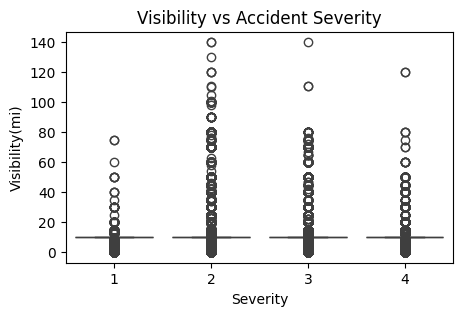

In [28]:
plt.figure(figsize=(5,3))
sns.boxplot(data = df , x='Severity' , y='Visibility(mi)')
plt.title('Visibility vs Accident Severity')
plt.show()

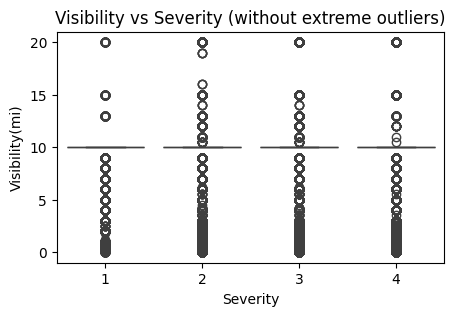

In [29]:
df_visible = df[df['Visibility(mi)']<=20]
plt.figure(figsize=(5,3))
sns.boxplot(data=df_visible , x='Severity', y='Visibility(mi)')
plt.title('Visibility vs Severity (without extreme outliers)')
plt.show()

#### Observation
- Median visibility is ~10 miles for all severities
- Heavy overlap among all the 4 severity levels
- Severe(3,4) accidents are clearly not happing at much lower visibility and many accidents occur even at lover visibility across all te severities
#### Conclusion
Visibility also is a weak predictor of severity

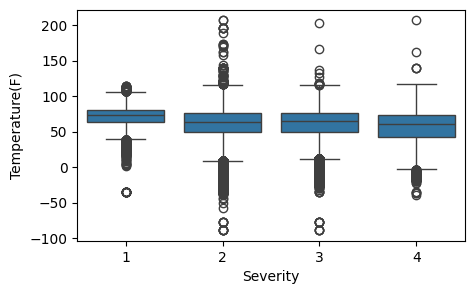

In [30]:
plt.figure(figsize=(5,3))
sns.boxplot(data=df , x='Severity' , y = 'Temperature(F)' )
plt.show()

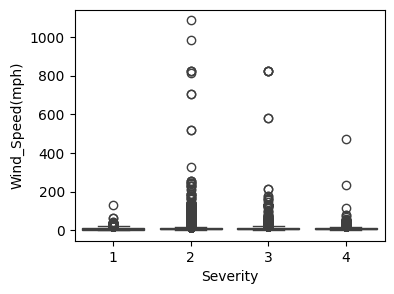

In [31]:
plt.figure(figsize=(4,3))
sns.boxplot(data = df , x ='Severity' , y = 'Wind_Speed(mph)')
plt.show()

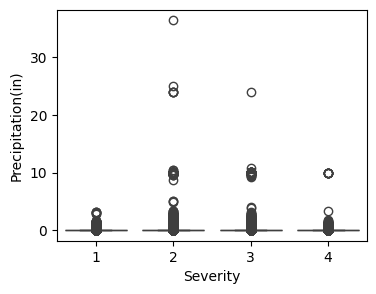

In [32]:
plt.figure(figsize=(4,3))
sns.boxplot(x='Severity', y='Precipitation(in)', data=df)
plt.show()

#### Observation
- We can observe neither precipitation and wind speed have much effect on the severity of the accidents
- Although a bit less Severity 1 accidents were observed during higher temperatures
- Precipitaion across severity levels overlap , with accidents also occuring at zero precipitation
#### Conclusion
- Precipitation alone may be a factor which can be combined iwth other features such as visibility or time of day for predictability.
- Severity may be influenced more by behavioural and infrastructural factors than weather alone.

In [33]:
pd.crosstab(df.Traffic_Signal,df.Severity,normalize='index')*100

Severity,1,2,3,4
Traffic_Signal,,,,
False,0.623043,78.186857,18.387206,2.802894
True,2.302994,88.188205,7.747086,1.761715


In [34]:
pd.crosstab(df.Junction,df.Severity,normalize='index')*100

Severity,1,2,3,4
Junction,,,,
False,0.897562,80.226356,16.303375,2.572707
True,0.547308,72.660333,23.190313,3.602046


In [35]:
pd.crosstab(df.Railway,df.Severity,normalize='index')*100

Severity,1,2,3,4
Railway,,,,
False,0.865401,79.635420,16.847541,2.651638
True,1.588558,83.281327,12.805506,2.324609


In [36]:
pd.crosstab(df.Stop,df.Severity,normalize='index')*100

Severity,1,2,3,4
Stop,,,,
False,0.861363,79.299611,17.190339,2.648688
True,1.232909,92.545167,3.569046,2.652877


In [37]:
pd.crosstab(df.Crossing,df.Severity,normalize='index')*100

Severity,1,2,3,4
Crossing,,,,
False,0.710104,78.245423,18.254885,2.789589
True,2.139138,90.819364,5.497143,1.544355


#### Observation 
- Infrastructure elements show different relationships with accident severity
- Junctions increase the proportions of severe accidents
- Traffic signals and stop signs are associated with lower severity levels
#### Explanation
- Controlled traffic systems reduce vehicle speed and manage traffic flow
- Junctions introduce multi direction conflicts increasing severity risk
#### Implication
- Infrastructure design plays a critical role in accident severity outcomes . Safety measures at junctions may significantly reduce high severity accidents

In [43]:
missing_percentage = df.isnull().mean()*100
missing_percentage = missing_percentage.sort_values(ascending=False)
missing_percentage[missing_percentage>0]

End_Lng              44.029355
End_Lat              44.029355
Precipitation(in)    28.512858
Wind_Chill(F)        25.865904
Wind_Speed(mph)       7.391355
Visibility(mi)        2.291524
Wind_Direction        2.267043
Humidity(%)           2.253301
Weather_Condition     2.244438
Temperature(F)        2.120143
Pressure(in)          1.820288
Sunrise_Sunset        0.300787
Street                0.140637
Timezone              0.101030
Zipcode               0.024779
City                  0.003274
dtype: float64

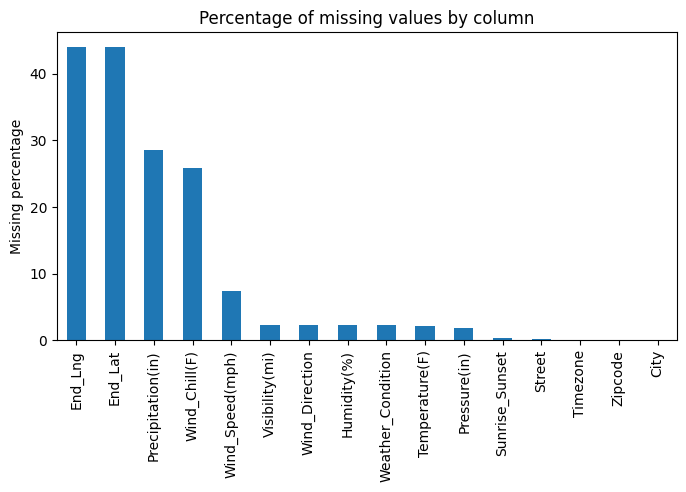

In [44]:
plt.figure(figsize=(8,4))
missing_percentage[missing_percentage>0].plot(kind='bar')
plt.title('Percentage of missing values by column')
plt.ylabel('Missing percentage')
plt.show()

In [45]:
df['Precipitation(in)'].isnull().groupby(df['Severity']).mean() * 100

Severity
1     5.813021
2    24.199620
3    49.285289
4    33.863514
Name: Precipitation(in), dtype: float64

In [61]:
df['Precipitation(in)'].where(df['Precipitation(in)']>0)

0          0.02
1           NaN
2           NaN
3           NaN
4           NaN
           ... 
7728389     NaN
7728390     NaN
7728391     NaN
7728392     NaN
7728393     NaN
Name: Precipitation(in), Length: 7728394, dtype: float32

In [68]:
df['Precipitation_Missing'] = df['Precipitation(in)'].isnull().astype(int)
df['Wind_Chill_Missing'] = df['Wind_Chill(F)'].isnull().astype(int)

In [69]:
df['Precipitation(in)'].fillna(df['Precipitation(in)'].median(), inplace=True)
df['Wind_Chill(F)'].fillna(df['Wind_Chill(F)'].median(), inplace=True)

C:\Users\arthj\AppData\Local\Temp\ipykernel_29792\2605484322.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Precipitation(in)'].fillna(df['Precipitation(in)'].median(), inplace=True)
C:\Users\arthj\AppData\Local\Temp\ipykernel_29792\2605484322.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alwa

In [75]:
df.drop(columns=['End_Lat','End_Lng'],inplace=True)
df.columns

Index(['Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'Distance(mi)', 'Street', 'City', 'County', 'State',
       'Zipcode', 'Timezone', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)',
       'Pressure(in)', 'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)',
       'Precipitation(in)', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing',
       'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station',
       'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Sunrise_Sunset', 'Hour',
       'Year', 'Month', 'Day_of_week', 'Precipitation_Missing',
       'Wind_Chill_Missing'],
      dtype='object')

In [63]:
df['Wind_Chill(F)'].isnull().groupby(df['Severity']).mean() * 100

Severity
1     3.279102
2    21.738479
3    46.104359
4    28.980021
Name: Wind_Chill(F), dtype: float64

In [66]:
df['Visibility(mi)'].isnull().groupby(df['Severity']).mean() * 100

Severity
1    1.387941
2    2.245208
3    2.348198
4    3.622197
Name: Visibility(mi), dtype: float64

In [67]:
df['Wind_Speed(mph)'].isnull().groupby(df['Severity']).mean() * 100

Severity
1     2.006947
2     6.478760
3    11.547889
4    10.228616
Name: Wind_Speed(mph), dtype: float64

#### Observation 
- We see that missingness in precipitation and wind_chilll increases with accident severity
- lower accidents show minimal missing weather data
- toher variable show mostly random and low missing data 
#### Explanation
- High severity accidents may occur in regions with imcomplete weather station coverage
- Weather APIs fail more frequrntly durign extreme conditions
#### Implication
- Missing weather data is not random and may contain predictive signal.
- Simple median inputation would have lost potentially valuable information.

In [70]:
numeric_df = df.select_dtypes(include=['int8' , 'int16' , 'int32' , 'int64' , 'float16' , 'float32' , 'float64'])

In [72]:
corr_mat = numeric_df.corr()
print(corr_mat)

                       Severity  Start_Lat  Start_Lng   End_Lat   End_Lng  \
Severity               1.000000   0.069060   0.052862  0.083724  0.093190   
Start_Lat              0.069060   1.000000  -0.067720  0.999993 -0.121743   
Start_Lng              0.052862  -0.067720   1.000000 -0.121735  0.999999   
End_Lat                0.083724   0.999993  -0.121735  1.000000 -0.121732   
End_Lng                0.093190  -0.121743   0.999999 -0.121732  1.000000   
Distance(mi)           0.034787   0.064064   0.007851  0.067932  0.005876   
Temperature(F)        -0.020327  -0.443781  -0.010652 -0.468692  0.024084   
Wind_Chill(F)         -0.041381  -0.422355  -0.031156 -0.459587  0.004800   
Humidity(%)            0.022293   0.022364   0.179500  0.027849  0.167428   
Pressure(in)           0.042347  -0.194094   0.193185 -0.242143  0.216028   
Visibility(mi)        -0.003473  -0.088500  -0.015322 -0.116199  0.006155   
Wind_Speed(mph)        0.040214   0.032908   0.077353  0.017373  0.092303   

<Axes: >

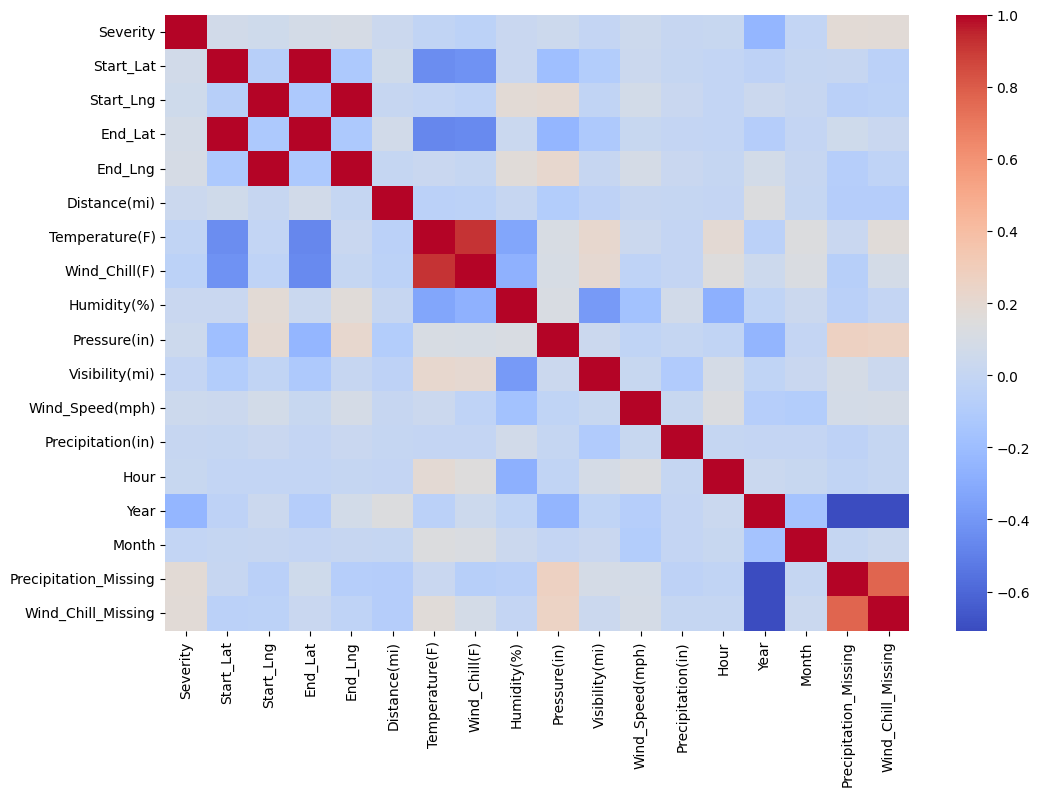

In [77]:
plt.figure(figsize=(12,8))
sns.heatmap(corr_mat,cmap='coolwarm')

In [78]:
corr_with_severity = corr_mat['Severity'].sort_values(ascending=False)
print(corr_with_severity)

Severity                 1.000000
Precipitation_Missing    0.180533
Wind_Chill_Missing       0.176330
End_Lng                  0.093190
End_Lat                  0.083724
Start_Lat                0.069060
Start_Lng                0.052862
Pressure(in)             0.042347
Wind_Speed(mph)          0.040214
Distance(mi)             0.034787
Humidity(%)              0.022293
Hour                     0.012661
Precipitation(in)        0.009159
Visibility(mi)          -0.003473
Month                   -0.010507
Temperature(F)          -0.020327
Wind_Chill(F)           -0.041381
Year                    -0.247046
Name: Severity, dtype: float64


# Key Findings and Modeling Direction

### What Patterns Exist ??
- Severity distribution is imbalanced
- Severity shows weak linear correlation with most numeric variables
- Year has moderate negative correlation suggesting decline over time
- Weather and road features show influence but not strong only benefactors
- No single major predictor present

### Why the Patterns exist 
- Accident severity depends on multiple interacting factors
- Improvement in infrastructure and safety overtime may explain the declining severity trend
- Weather and time of the day does not have much effect on the number of accidents
- Lack of data collection before time may influence some patterns

## Future Plans
- Build a classification model to predict Severity
- Handle class imbalance using class weights or resampling
- Use tree based models (Random Forest , XGBoost) to capture non-lineat interactions.
- Remove redunctant features to avoid multicollinearity
- Evaluate using F1-score dueto imbalance